# Reusable quench-dynamics experiment

This notebook repeats the validated $U_i/t=100\rightarrow U_f/t=5$ Hubbard-dimer experiment from notebook 03, but imports all reusable physics operations from `src/quantum_hubbard`. The notebook is intentionally thin: it selects parameters, runs the experiment, checks physical invariants, and plots results.

The benchmark follows the closed-system ($\Gamma=0$) quench in [Zavatti, Bellomia, and Capone, arXiv:2605.18494](https://arxiv.org/abs/2605.18494).

## 1. Imports and experiment parameters

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from qiskit.quantum_info import SparsePauliOp
from scipy.sparse import SparseEfficiencyWarning

from quantum_hubbard import (
    analytic_singlet_energies,
    analytic_singlet_state,
    average_double_occupancy_operator,
    build_suzuki_trotter_step,
    dimer_quench_frequency,
    double_occupancy_operator,
    exact_trajectory,
    hubbard_hamiltonian,
    local_double_occupancy_operator,
    particle_number_operator,
    solve_particle_sector,
    spin_z_correlation_operator,
    total_spin_z_operator,
    trajectory_expectation,
    trotter_trajectory,
)
from quantum_hubbard.operators import pauli_decomposition

warnings.filterwarnings("ignore", category=SparseEfficiencyWarning)
plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=8, suppress=True)
ATOL = 1e-10

In [2]:
hopping = 1.0
u_initial = 100.0
u_final = 5.0
num_particles = 2
periods_to_show = 4
steps_per_period = 80

H_initial = hubbard_hamiltonian(t=hopping, u=u_initial)
H_final = hubbard_hamiltonian(t=hopping, u=u_final)
psi_initial = solve_particle_sector(
    H_initial, num_particles=num_particles
).ground_state

omega = dimer_quench_frequency(t=hopping, u_final=u_final)
oscillation_period = 2 * np.pi / omega
num_steps = periods_to_show * steps_per_period
times = np.linspace(0.0, periods_to_show * oscillation_period, num_steps + 1)
time_step = times[1] - times[0]

print(f"Quench: U_i/t = {u_initial / hopping:g} -> U_f/t = {u_final / hopping:g}")
print(f"Frequency: omega = {omega:.8f}")
print(f"Period: T = {oscillation_period:.8f}")
print(f"Time step: Delta tau = {time_step:.8f}")

Quench: U_i/t = 100 -> U_f/t = 5
Frequency: omega = 6.40312424
Period: T = 0.98126869
Time step: Delta tau = 0.01226586


## 2. Exact trajectory and analytic literature reference

The reusable exact propagator diagonalizes $H(U_f)$ once. Independently, the analytic dimer solution expands the initial state in the two even-parity singlet eigenstates of the final Hamiltonian.

In [3]:
exact_states = exact_trajectory(H_final, psi_initial, times)

psi_initial_analytic = analytic_singlet_state(
    t=hopping, u=u_initial, branch="ground"
)
psi_minus_final = analytic_singlet_state(
    t=hopping, u=u_final, branch="ground"
)
psi_plus_final = analytic_singlet_state(
    t=hopping, u=u_final, branch="excited"
)
energy_minus, energy_plus = analytic_singlet_energies(
    t=hopping, u=u_final
)
alpha = np.vdot(psi_minus_final, psi_initial_analytic)
beta = np.vdot(psi_plus_final, psi_initial_analytic)
analytic_states = np.asarray(
    [
        alpha * np.exp(-1j * energy_minus * time) * psi_minus_final
        + beta * np.exp(-1j * energy_plus * time) * psi_plus_final
        for time in times
    ]
)

initial_fidelity = abs(np.vdot(psi_initial_analytic, psi_initial)) ** 2
trajectory_fidelities = np.abs(
    np.einsum("ti,ti->t", analytic_states.conj(), exact_states)
) ** 2
assert np.isclose(initial_fidelity, 1.0, atol=ATOL)
assert np.allclose(trajectory_fidelities, 1.0, atol=ATOL)
assert np.isclose(energy_plus - energy_minus, omega, atol=ATOL)

print(f"Initial-state fidelity: {initial_fidelity:.12f}")
print(f"Minimum analytic/exact fidelity: {trajectory_fidelities.min():.12f}")

Initial-state fidelity: 1.000000000000
Minimum analytic/exact fidelity: 1.000000000000


## 3. Measure observables and conservation laws

In [4]:
D_0 = local_double_occupancy_operator(0)
D_1 = local_double_occupancy_operator(1)
D_total = double_occupancy_operator()
D_average = average_double_occupancy_operator()
C_zz = spin_z_correlation_operator(0, 1)
N_total = particle_number_operator()
S_z_total = total_spin_z_operator()

double_0_exact = trajectory_expectation(exact_states, D_0)
double_1_exact = trajectory_expectation(exact_states, D_1)
double_total_exact = trajectory_expectation(exact_states, D_total)
double_average_exact = trajectory_expectation(exact_states, D_average)
czz_exact = trajectory_expectation(exact_states, C_zz)
norms = np.sum(np.abs(exact_states) ** 2, axis=1)
energies = trajectory_expectation(exact_states, H_final)
particle_numbers = trajectory_expectation(exact_states, N_total)
total_spin_z = trajectory_expectation(exact_states, S_z_total)

assert np.allclose(double_0_exact, double_1_exact, atol=ATOL)
assert np.allclose(double_total_exact, double_0_exact + double_1_exact, atol=ATOL)
assert np.allclose(double_average_exact, 0.5 * double_total_exact, atol=ATOL)
assert np.isclose(double_average_exact[0], double_average_exact[steps_per_period], atol=ATOL)
assert np.allclose(norms, 1.0, atol=ATOL)
assert np.allclose(energies, energies[0], atol=ATOL)
assert np.allclose(particle_numbers, num_particles, atol=ATOL)
assert np.allclose(total_spin_z, 0.0, atol=ATOL)

print(
    "Per-site double-occupancy range: "
    f"[{double_average_exact.min():.8f}, {double_average_exact.max():.8f}]"
)
print(f"Maximum norm drift: {np.max(np.abs(norms - 1)):.3e}")
print(f"Maximum post-quench energy drift: {np.max(np.abs(energies - energies[0])):.3e}")

Per-site double-occupancy range: [0.00019976, 0.18541750]
Maximum norm drift: 1.332e-15
Maximum post-quench energy drift: 6.661e-16


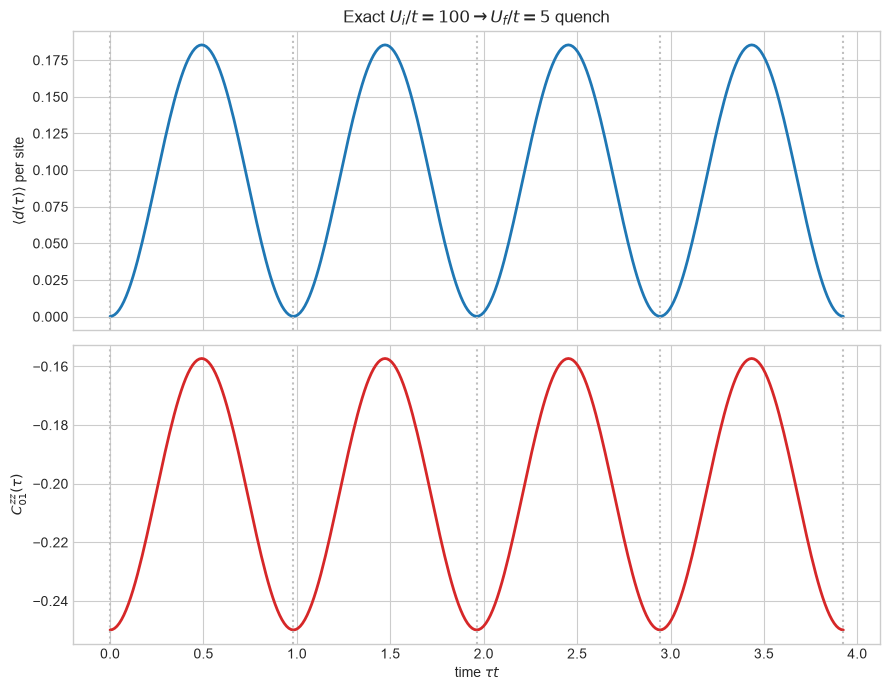

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
axes[0].plot(times, double_average_exact, color="tab:blue", lw=2)
axes[0].set_ylabel(r"$\langle d(\tau)\rangle$ per site")
axes[0].set_title(r"Exact $U_i/t=100\rightarrow U_f/t=5$ quench")

axes[1].plot(times, czz_exact, color="tab:red", lw=2)
axes[1].set_xlabel(r"time $\tau t$")
axes[1].set_ylabel(r"$C_{01}^{zz}(\tau)$")

for axis in axes:
    for period_index in range(periods_to_show + 1):
        axis.axvline(period_index * oscillation_period, color="0.75", ls=":")
fig.tight_layout()
plt.show()

## 4. Trotterized qubit experiment

The source API separately constructs one decomposed second-order Suzuki step and applies it repeatedly. This makes the circuit available for resource inspection while keeping the trajectory runner independent of how the step was synthesized.

In [6]:
pauli_terms = pauli_decomposition(H_final)
H_qubit = SparsePauliOp.from_list(list(pauli_terms.items()))
assert np.allclose(H_qubit.to_matrix(), H_final, atol=ATOL)

trotter_step = build_suzuki_trotter_step(
    H_qubit, time_step=time_step, order=2, reps=1
)
trotter_states = trotter_trajectory(
    psi_initial, step_circuit=trotter_step, num_steps=num_steps
)
double_average_trotter = trajectory_expectation(trotter_states, D_average)
czz_trotter = trajectory_expectation(trotter_states, C_zz)
double_error = double_average_trotter - double_average_exact

print(f"One-step circuit depth: {trotter_step.depth()}")
print(f"One-step operations: {dict(trotter_step.count_ops())}")
print(f"Max |double-occupancy error|: {np.max(np.abs(double_error)):.3e}")

One-step circuit depth: 15
One-step operations: {'rz': 8, 'rxx': 4, 'ryy': 4, 'rzz': 3}
Max |double-occupancy error|: 1.606e-04


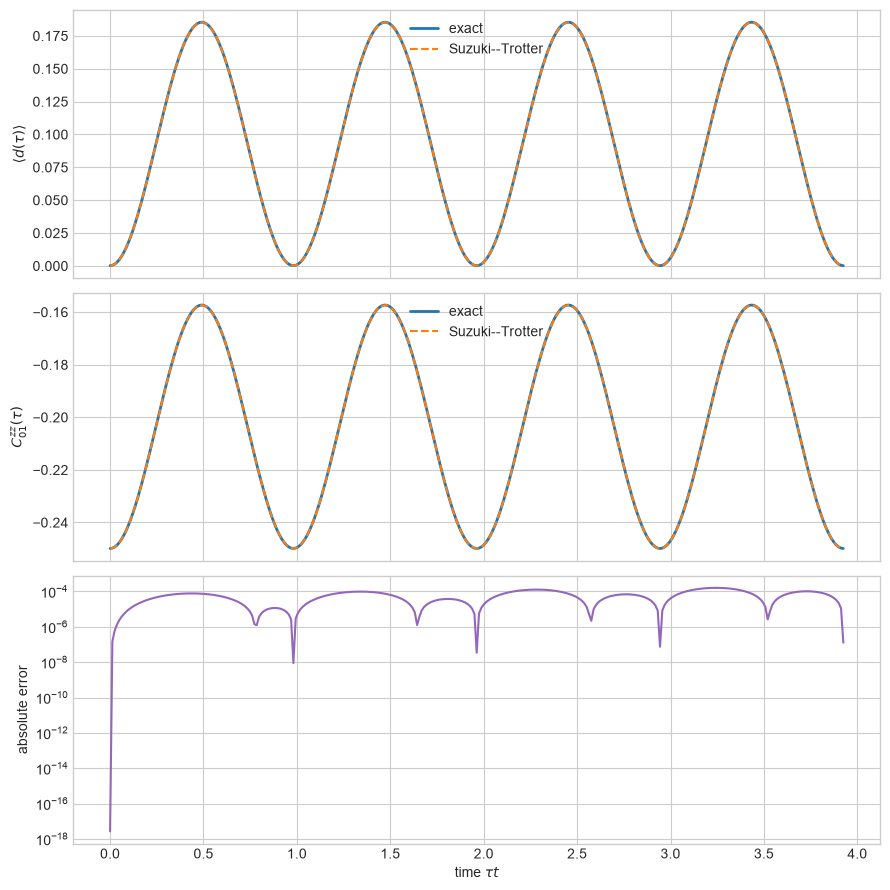

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9), sharex=True)
axes[0].plot(times, double_average_exact, label="exact", lw=2)
axes[0].plot(times, double_average_trotter, "--", label="Suzuki--Trotter")
axes[0].set_ylabel(r"$\langle d(\tau)\rangle$")
axes[0].legend()

axes[1].plot(times, czz_exact, label="exact", lw=2)
axes[1].plot(times, czz_trotter, "--", label="Suzuki--Trotter")
axes[1].set_ylabel(r"$C_{01}^{zz}(\tau)$")
axes[1].legend()

axes[2].plot(times, np.abs(double_error), color="tab:purple")
axes[2].set_yscale("log")
axes[2].set_xlabel(r"time $\tau t$")
axes[2].set_ylabel("absolute error")
fig.tight_layout()
plt.show()

## 5. Second-order convergence experiment

Delta tau = 0.04906343: max error = 1.565262e-03
Delta tau = 0.02453172: max error = 3.933355e-04
Delta tau = 0.01226586: max error = 9.851640e-05
Observed convergence order: 1.9949


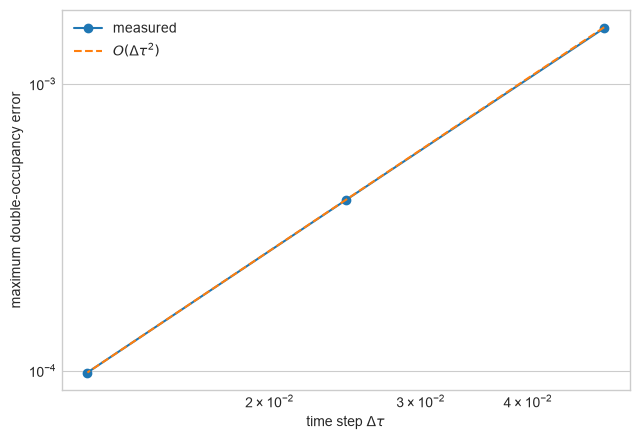

In [8]:
steps_per_period_values = np.array([20, 40, 80])
time_steps = oscillation_period / steps_per_period_values
max_errors = []

for steps_in_period, convergence_dt in zip(steps_per_period_values, time_steps):
    convergence_steps = 2 * int(steps_in_period)
    convergence_times = np.arange(convergence_steps + 1) * convergence_dt
    convergence_exact = exact_trajectory(H_final, psi_initial, convergence_times)
    convergence_step = build_suzuki_trotter_step(
        H_qubit, time_step=convergence_dt, order=2
    )
    convergence_trotter = trotter_trajectory(
        psi_initial, convergence_step, convergence_steps
    )
    exact_d = trajectory_expectation(convergence_exact, D_average)
    trotter_d = trajectory_expectation(convergence_trotter, D_average)
    max_errors.append(np.max(np.abs(trotter_d - exact_d)))

max_errors = np.asarray(max_errors)
observed_order = np.polyfit(np.log(time_steps), np.log(max_errors), 1)[0]
assert np.all(np.diff(max_errors) < 0)
assert 1.8 < observed_order < 2.2

for dt_value, error in zip(time_steps, max_errors):
    print(f"Delta tau = {dt_value:.8f}: max error = {error:.6e}")
print(f"Observed convergence order: {observed_order:.4f}")

fig, axis = plt.subplots(figsize=(6.5, 4.5))
axis.loglog(time_steps, max_errors, "o-", label="measured")
reference = max_errors[-1] * (time_steps / time_steps[-1]) ** 2
axis.loglog(time_steps, reference, "--", label=r"$O(\Delta\tau^2)$")
axis.set_xlabel(r"time step $\Delta\tau$")
axis.set_ylabel("maximum double-occupancy error")
axis.legend()
fig.tight_layout()
plt.show()

## 6. Result

The experiment reproduces the notebook-03 baseline using only reusable source operations: analytic dimer states, exact propagation, observable construction, trajectory expectations, Trotter-step synthesis, and repeated circuit evolution. Experiment parameters, assertions, plots, and interpretation remain in the notebook.